# Practice 14 — Dataloader for Image

표(table) 형태 데이터의 DataLoader 패턴을 **이미지 데이터** 로 확장합니다.

| 섹션 | 내용 |
|------|------|
| 1 | torchvision 내장 데이터셋 (CIFAR-10) + 기본 transform |
| 2 | Custom Dataset 클래스 — 임의의 numpy 데이터를 감싸기 |
| 3 | ImageFolder — 폴더 구조에서 자동 로드 (자기 사진도 그대로 활용 가능) |
| 4 | 데이터 증강 (Augmentation) transform — `RandomCrop`, `HorizontalFlip` 등 |

이 노트북은 **데이터 준비만** 다룹니다.


In [1]:
# Windows + conda 환경에서 torch와 torchvision 동시 로드 시 OpenMP 충돌 회피
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)


torch: 2.6.0+cu124
torchvision: 0.21.0+cu124


---
# 1. torchvision 내장 데이터셋 + 기본 transform

**CIFAR-10**: 32x32 컬러 사진, 10클래스 (plane, car, bird, cat, deer, dog, frog, horse, ship, truck).

`torchvision.datasets.CIFAR10` 한 줄로 자동 다운로드. `transform` 인자로 매 이미지에 적용할 변환을 전달합니다.

**기본 transform 두 가지:**
- `ToTensor()` : PIL Image → `(C, H, W)` float 텐서 (0~1 범위)
- `Normalize(mean, std)` : 채널별 표준화 (학습 안정화)


In [2]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2440, 0.2620)

transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)
class_names = trainset.classes
print(f'Train: {len(trainset)},  Test: {len(testset)}')
print(f'Classes: {class_names}')

# 한 샘플 확인
img, label = trainset[0]
print(f'Image shape: {tuple(img.shape)} (C, H, W),  label: {class_names[label]}')


Train: 50000,  Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape: (3, 32, 32) (C, H, W),  label: frog


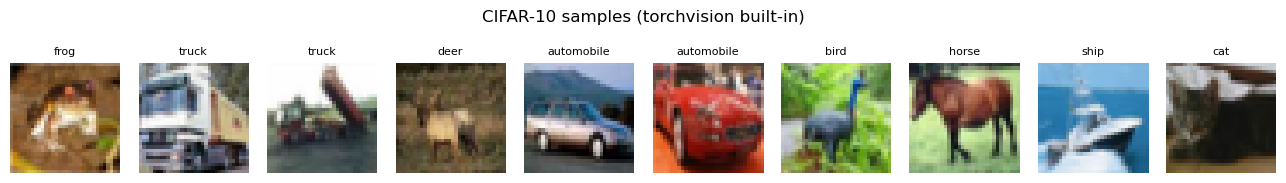

In [3]:
# 정규화된 텐서를 다시 표시 가능한 이미지로 되돌리는 헬퍼
mean_arr = np.array(CIFAR_MEAN)
std_arr  = np.array(CIFAR_STD)
def unnormalize(img_t):
    img = img_t.permute(1, 2, 0).numpy() * std_arr + mean_arr
    return np.clip(img, 0, 1)

# 샘플 10장
fig, axes = plt.subplots(1, 10, figsize=(13, 1.7))
for i in range(10):
    img_i, label_i = trainset[i]
    axes[i].imshow(unnormalize(img_i))
    axes[i].set_title(class_names[label_i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 samples (torchvision built-in)', y=1.05)
plt.tight_layout(); plt.show()


---
# 2. Custom Dataset 클래스

내장 데이터셋이 없는 경우 (예: numpy 배열 형태로 가진 임의 데이터), 직접 `Dataset` 클래스를 만들어야 합니다.

| 메서드 | 역할 |
|--------|------|
| `__init__` | 데이터(X, y)와 transform 보관 |
| `__len__` | 전체 샘플 수 |
| `__getitem__(idx)` | idx번째 샘플 반환, 필요 시 transform 적용 |

`DataLoader` 가 매 배치마다 `__getitem__` 을 호출합니다. transform 도 그 안에서 매번 호출되므로 **랜덤 증강이 sample 단위로 자연스럽게 작동**합니다.

아래 9줄짜리 템플릿을 그대로 외워두고 사용하면 됩니다.


In [4]:
class CIFAR10Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X                        # numpy uint8 (N, 32, 32, 3)
        self.y = y                        # numpy int    (N,)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = Image.fromarray(self.X[idx])   # numpy -> PIL (transform 입력 형식)
        if self.transform is not None:
            img = self.transform(img)
        return img, self.y[idx]


Custom set length: 200
Batch X shape: (8, 3, 32, 32)  (N, C, H, W)
Batch y shape: (8,)


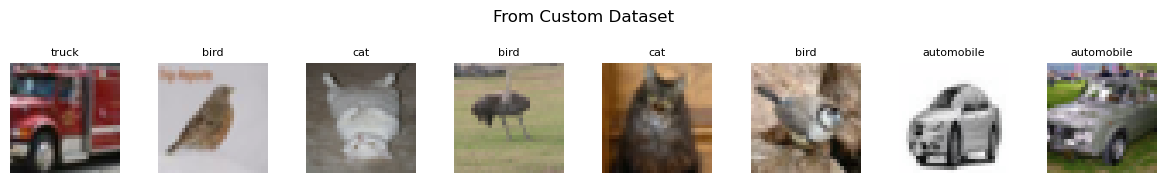

In [5]:
# CIFAR-10 을 numpy 로 직접 받아서 (transform 없이) Custom Dataset 으로 감싸기
cifar_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
X = cifar_raw.data[:200]                  # (200, 32, 32, 3)
y = np.array(cifar_raw.targets[:200])

custom_set = CIFAR10Dataset(X, y, transform=transform_basic)
print(f'Custom set length: {len(custom_set)}')

# DataLoader 한 줄
custom_loader = DataLoader(custom_set, batch_size=8, shuffle=True)
batch_X, batch_y = next(iter(custom_loader))
print(f'Batch X shape: {tuple(batch_X.shape)}  (N, C, H, W)')
print(f'Batch y shape: {tuple(batch_y.shape)}')

# 한 배치 시각화
fig, axes = plt.subplots(1, 8, figsize=(12, 1.7))
for i in range(8):
    axes[i].imshow(unnormalize(batch_X[i]))
    axes[i].set_title(class_names[batch_y[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('From Custom Dataset', y=1.05)
plt.tight_layout(); plt.show()


---
# 3. ImageFolder — 폴더 구조에서 자동 로드

가장 일반적인 패턴 중 하나. 디스크에 다음과 같이 정리되어 있으면:

```
data_root/
├── plane/   img_000.png   img_001.png   ...
├── car/     ...
└── bird/    ...
```

`ImageFolder(root, transform)` 한 줄로 자동 데이터셋 생성. 폴더명이 곧 클래스명이 됩니다.

> **자기 사진을 학습**하고 싶다면 — `data/my_photos/<클래스명>/<파일.jpg>` 형태로 폴더만 만들면 같은 코드 한 줄로 DataLoader 완성.

여기서는 미리 준비한 **CIFAR5 ImageFolder** (5클래스 × train 100장 / test 50장 = 총 750장, ~2MB)를 GitHub Release에서 다운로드해 사용합니다.


In [6]:
import urllib.request
import zipfile

ROOT = './data/cifar5_imagefolder'
URL  = 'https://github.com/jongmoonha/Ajou_ME_ML_Undergraduate/releases/download/data-v1/cifar5_imagefolder.zip'

if not os.path.exists(ROOT):
    os.makedirs('./data', exist_ok=True)
    print('Downloading CIFAR5 ImageFolder (~2MB)...')
    urllib.request.urlretrieve(URL, './data/cifar5_imagefolder.zip')
    with zipfile.ZipFile('./data/cifar5_imagefolder.zip') as zf:
        zf.extractall('./data/')
    os.remove('./data/cifar5_imagefolder.zip')
    print('Done.')

# 폴더 구조 확인
selected_class_names = sorted(os.listdir(f'{ROOT}/train'))
for split in ['train', 'test']:
    counts = {c: len(os.listdir(f'{ROOT}/{split}/{c}')) for c in selected_class_names}
    print(f'{split}: {counts}')


train: {'bird': 100, 'car': 100, 'cat': 100, 'deer': 100, 'plane': 100}
test: {'bird': 50, 'car': 50, 'cat': 50, 'deer': 50, 'plane': 50}


Samples      : 500
Classes      : ['bird', 'car', 'cat', 'deer', 'plane']
Class -> idx : {'bird': 0, 'car': 1, 'cat': 2, 'deer': 3, 'plane': 4}


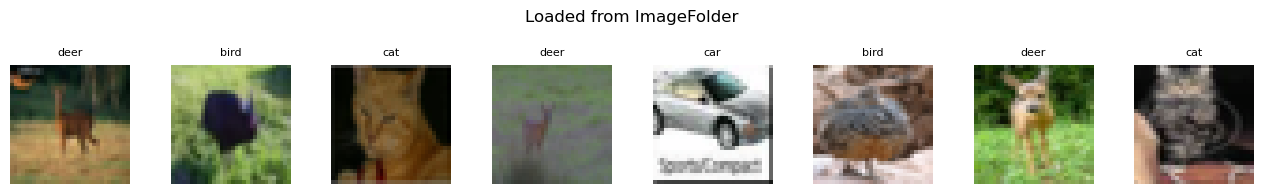

In [7]:
# ImageFolder 한 줄로 데이터셋 생성
imgfolder_train = torchvision.datasets.ImageFolder(
    root=f'{ROOT}/train',
    transform=transform_basic)

print(f'Samples      : {len(imgfolder_train)}')
print(f'Classes      : {imgfolder_train.classes}')
print(f'Class -> idx : {imgfolder_train.class_to_idx}')

# DataLoader 도 한 줄
imgfolder_loader = DataLoader(imgfolder_train, batch_size=8, shuffle=True)
batch_X, batch_y = next(iter(imgfolder_loader))

fig, axes = plt.subplots(1, 8, figsize=(13, 1.8))
for i in range(8):
    axes[i].imshow(unnormalize(batch_X[i]))
    axes[i].set_title(imgfolder_train.classes[batch_y[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Loaded from ImageFolder', y=1.05)
plt.tight_layout(); plt.show()


---
# 4. 데이터 증강 (Data Augmentation) transform

학습 시 매 epoch 마다 입력에 **랜덤 변환** 을 적용 → 사실상 데이터 양이 늘어나는 효과 → 과적합 억제.

**CIFAR-10 표준 조합:**
- `RandomCrop(32, padding=4)` : 가장자리 0 패딩 후 랜덤 위치에서 32x32 자르기
- `RandomHorizontalFlip(p=0.5)` : 50% 확률로 좌우 반전 (자연 객체는 좌우 대칭)

**Custom Dataset / ImageFolder / 내장 데이터셋 모두 동일**: `transform` 인자에 augmentation transform 을 넘기면 매 `__getitem__` 호출 시 (즉 매 배치 매 sample 마다) 다른 변환이 적용됩니다.



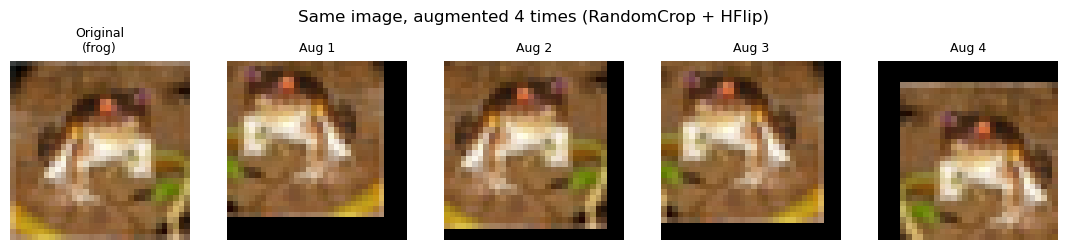

→ augmentation 은 학습 데이터를 그대로 두고 매 배치마다 변형해 다양성을 확보합니다.
→ test set 에는 적용하지 않습니다 (평가는 결정론적으로).


In [8]:
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 같은 이미지에 augmentation 을 4번 적용 - 매번 다른 결과
aug_set = CIFAR10Dataset(X, y, transform=transform_aug)

torch.manual_seed(0)
img_orig, label_orig = custom_set[0]   # 증강 없음 (transform_basic)

fig, axes = plt.subplots(1, 5, figsize=(11, 2.5))
axes[0].imshow(unnormalize(img_orig))
axes[0].set_title(f'Original\n({class_names[label_orig]})', fontsize=9)
axes[0].axis('off')
for i in range(4):
    img_i, _ = aug_set[0]              # 매번 다른 변환
    axes[i+1].imshow(unnormalize(img_i))
    axes[i+1].set_title(f'Aug {i+1}', fontsize=9)
    axes[i+1].axis('off')
plt.suptitle('Same image, augmented 4 times (RandomCrop + HFlip)')
plt.tight_layout(); plt.show()

print('→ augmentation 은 학습 데이터를 그대로 두고 매 배치마다 변형해 다양성을 확보합니다.')
print('→ test set 에는 적용하지 않습니다 (평가는 결정론적으로).')


---
## 정리

| 패턴 | 언제 사용 |
|------|----------|
| `torchvision.datasets.CIFAR10` 같은 내장 데이터셋 | 잘 알려진 표준 데이터셋 |
| **Custom Dataset 클래스** | numpy / tensor 등 임의 형식 데이터, 가장 일반적 |
| **ImageFolder** | 폴더 구조로 정리된 파일 (사용자 사진 그대로 활용) |
| **Augmentation transform** | 학습 시 데이터 다양성 확보 (test 에는 적용 X) |
